# 🤖 AI Impact on Jobs 2030 — Data Visualisation

**Dataset** : `AI_Impact_on_Jobs_2030.csv`  
**Objectif** : Explorer l'impact de l'IA sur l'emploi à travers 6 visualisations rigoureuses.  
**Variables clés** : `Job_Title`, `Average_Salary`, `Years_Experience`, `Education_Level`, `AI_Exposure_Index`, `Tech_Growth_Factor`, `Automation_Probability_2030`, `Risk_Category`

---

## 0. Imports & Configuration globale

In [2]:
! pip install pandas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# ── Design system (thème dark cohérent) ─────────────────────────────────────
BG       = '#0F1117'
BG2      = '#181C27'
GRID_COL = '#252A3A'
TEXT     = '#E8EAF0'
TEXT_DIM = '#7A8099'
LOW_C    = '#00C896'   # vert  → faible risque
MED_C    = '#F5A623'   # ambre → risque moyen
HIGH_C   = '#FF4560'   # rouge → risque élevé

RISK_COL  = {'Low': LOW_C, 'Medium': MED_C, 'High': HIGH_C}
EDU_ORDER = ["High School", "Bachelor's", "Master's", "PhD"]

# ── Formatters ───────────────────────────────────────────────────────────────
pct = FuncFormatter(lambda y, _: f'{y:.0%}')
usd = FuncFormatter(lambda y, _: f'${y/1000:.0f}k')

# ── Helpers ──────────────────────────────────────────────────────────────────
def apply_style(ax, fig):
    fig.set_facecolor(BG)
    ax.set_facecolor(BG2)
    ax.tick_params(colors=TEXT_DIM, labelsize=10)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(GRID_COL)
    ax.grid(color=GRID_COL, linestyle='--', linewidth=0.6, alpha=0.7)

def add_subtitle(ax, text):
    ax.annotate(text, xy=(0, 1.01), xycoords='axes fraction',
                fontsize=9, color=TEXT_DIM, va='bottom')

def add_source(ax):
    ax.annotate('Source : AI Impact on Jobs 2030 — n = 3 000',
                xy=(1, -0.09), xycoords='axes fraction',
                ha='right', fontsize=8, color=TEXT_DIM, style='italic')

print('✅ Configuration chargée.')

✅ Configuration chargée.


## 1. Chargement & nettoyage des données

In [4]:
# ⚠️ Adapter le chemin si nécessaire
df = pd.read_csv('dataset_ressources/AI_Impact_on_Jobs_2030.csv')

print(f'Shape : {df.shape}')
print(f'Colonnes : {df.columns.tolist()}')
print(f'\nValeurs manquantes :\n{df.isnull().sum()}')
print(f'\nRisk_Category :\n{df["Risk_Category"].value_counts()}')
print(f'\nEducation_Level :\n{df["Education_Level"].value_counts()}')
df.describe()

Shape : (3000, 18)
Colonnes : ['Job_Title', 'Average_Salary', 'Years_Experience', 'Education_Level', 'AI_Exposure_Index', 'Tech_Growth_Factor', 'Automation_Probability_2030', 'Risk_Category', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8', 'Skill_9', 'Skill_10']

Valeurs manquantes :
Job_Title                      0
Average_Salary                 0
Years_Experience               0
Education_Level                0
AI_Exposure_Index              0
Tech_Growth_Factor             0
Automation_Probability_2030    0
Risk_Category                  0
Skill_1                        0
Skill_2                        0
Skill_3                        0
Skill_4                        0
Skill_5                        0
Skill_6                        0
Skill_7                        0
Skill_8                        0
Skill_9                        0
Skill_10                       0
dtype: int64

Risk_Category :
Risk_Category
Medium    1521
High       740
Low    

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,89372.279000,14.677667,0.501283,0.995343,0.501503,0.496973,0.497233,0.499313,0.503667,0.490270,0.499807,0.499160,0.502843,0.501433,0.493627
std,34608.088767,8.739788,0.284004,0.287669,0.247881,0.287888,0.288085,0.288354,0.287063,0.285818,0.286050,0.288044,0.289832,0.285818,0.286464
min,30030.000000,0.000000,0.000000,0.500000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58640.000000,7.000000,0.260000,0.740000,0.310000,0.240000,0.250000,0.250000,0.260000,0.240000,0.260000,0.250000,0.250000,0.260000,0.250000
50%,89318.000000,15.000000,0.500000,1.000000,0.500000,0.505000,0.500000,0.500000,0.510000,0.490000,0.500000,0.490000,0.500000,0.500000,0.490000
75%,119086.500000,22.000000,0.740000,1.240000,0.700000,0.740000,0.740000,0.750000,0.750000,0.730000,0.740000,0.750000,0.750000,0.740000,0.740000
max,149798.000000,29.000000,1.000000,1.500000,0.950000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# Agrégation au niveau job title (utilisée dans plusieurs graphiques)
jobs = df.groupby('Job_Title').agg(
    salary       = ('Average_Salary',              'mean'),
    automation   = ('Automation_Probability_2030',  'mean'),
    exposure     = ('AI_Exposure_Index',            'mean'),
    tech_growth  = ('Tech_Growth_Factor',           'mean'),
    count        = ('Job_Title',                    'count'),
    risk         = ('Risk_Category', lambda x: x.value_counts().idxmax())
).reset_index()

print(f'{len(jobs)} métiers distincts')
jobs.sort_values('automation')

20 métiers distincts


,Job_Title,salary,automation,exposure,tech_growth,count,risk
0,AI Engineer,90759.828571,0.172214,0.474286,0.978500,140,Low
13,Research Scientist,87204.744966,0.174161,0.478591,0.962081,149,Low
12,Nurse,88955.323944,0.175634,0.520563,0.986408,142,Low
17,Teacher,90885.759036,0.175783,0.497289,1.008795,166,Low
5,Doctor,89091.742424,0.176742,0.505152,0.963788,132,Low
6,Financial Analyst,88030.311258,0.485099,0.464437,1.027815,151,Medium
11,Mechanic,89807.647059,0.485294,0.456544,0.976471,136,Medium
9,Lawyer,92441.878788,0.486439,0.509015,1.015076,132,Medium
8,HR Specialist,89242.254777,0.490764,0.489236,0.986815,157,Medium
19,UX Researcher,87982.419162,0.492395,0.475988,0.986886,167,Medium


---
## 📊 Graphique 1 — Bubble Chart : Salaire × Probabilité d'automatisation

**Lecture** : chaque bulle = 1 métier. Sa taille reflète l'exposition à l'IA (`AI_Exposure_Index`). Sa couleur indique la catégorie de risque dominante.

**Question** : les métiers bien payés sont-ils mieux protégés de l'automatisation ?

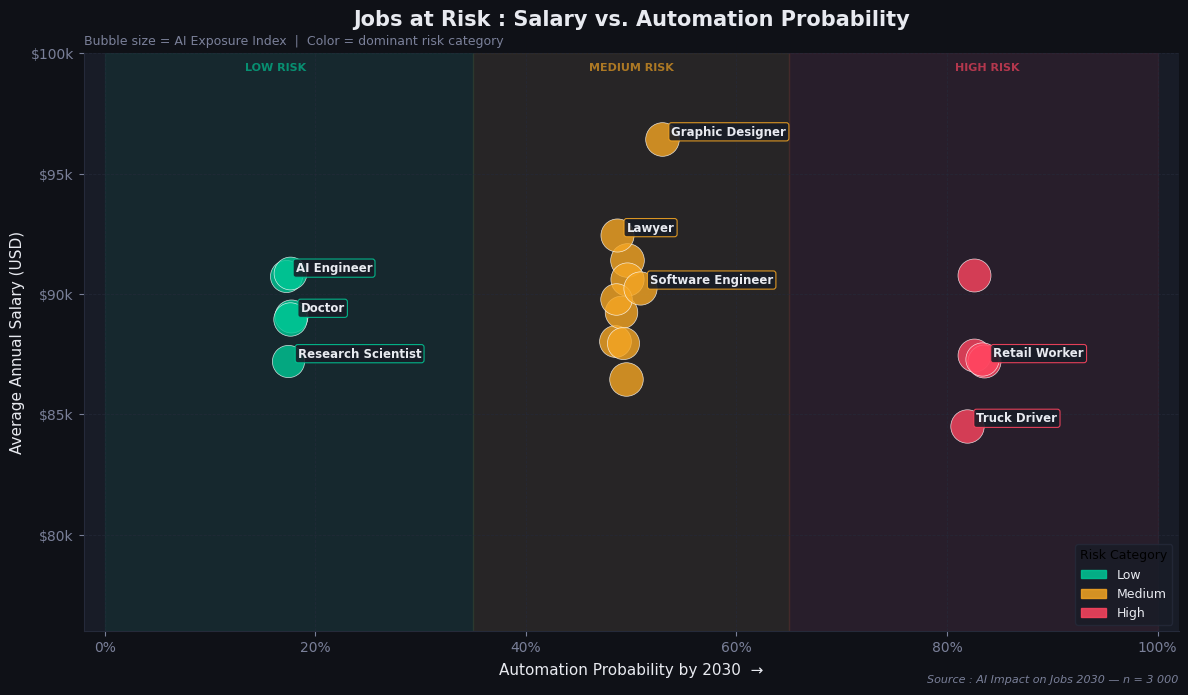

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
apply_style(ax, fig)
fig.subplots_adjust(left=0.10, right=0.90, top=0.87, bottom=0.13)

for _, row in jobs.iterrows():
    col = RISK_COL[row['risk']]
    sz  = row['exposure'] * 1000 + 60
    ax.scatter(row['automation'], row['salary'], s=sz,
               color=col, alpha=0.80, edgecolors='white', linewidths=0.5, zorder=3)

# Zones de risque
ax.axvspan(0,    0.35, alpha=0.07, color=LOW_C,  zorder=0)
ax.axvspan(0.35, 0.65, alpha=0.07, color=MED_C,  zorder=0)
ax.axvspan(0.65, 1.0,  alpha=0.07, color=HIGH_C, zorder=0)
for xc, lbl, col in [(0.175,'LOW RISK',LOW_C),(0.50,'MEDIUM RISK',MED_C),(0.825,'HIGH RISK',HIGH_C)]:
    ax.text(xc, 0.97, lbl, ha='center', fontsize=8, color=col,
            fontweight='bold', alpha=0.65, transform=ax.transAxes)

# Annotations des métiers clés
for jb in ['AI Engineer','Retail Worker','Truck Driver','Graphic Designer',
           'Lawyer','Doctor','Research Scientist','Software Engineer']:
    row = jobs[jobs['Job_Title'] == jb].iloc[0]
    ax.annotate(jb, xy=(row['automation'], row['salary']),
                xytext=(7, 3), textcoords='offset points',
                fontsize=8.5, color=TEXT, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.22', fc=BG2,
                          ec=RISK_COL[row['risk']], alpha=0.88, lw=0.8))

ax.set_xlabel('Automation Probability by 2030  →', fontsize=11, labelpad=6)
ax.set_ylabel('Average Annual Salary (USD)', fontsize=11)
ax.set_title('Jobs at Risk : Salary vs. Automation Probability',
             fontsize=15, fontweight='bold', color=TEXT, pad=20)
add_subtitle(ax, 'Bubble size = AI Exposure Index  |  Color = dominant risk category')
ax.xaxis.set_major_formatter(pct)
ax.yaxis.set_major_formatter(usd)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(76000, 100000)

legend_patches = [mpatches.Patch(color=c, label=r, alpha=0.85) for r, c in RISK_COL.items()]
ax.legend(handles=legend_patches, title='Risk Category', loc='lower right',
          title_fontsize=9, fontsize=9, facecolor=BG2, edgecolor=GRID_COL, labelcolor=TEXT)
add_source(ax)
plt.tight_layout()
plt.show()

**Analyse** : Le salaire ne protège pas du risque d'automatisation. Les métiers à risque élevé (rouge) sont dispersés sur toute la plage salariale, tout comme les métiers à faible risque (vert).

---
## 📊 Graphique 2 — Lollipop : Classement des métiers par risque d'automatisation

**Question** : quels métiers sont les plus et les moins menacés ?

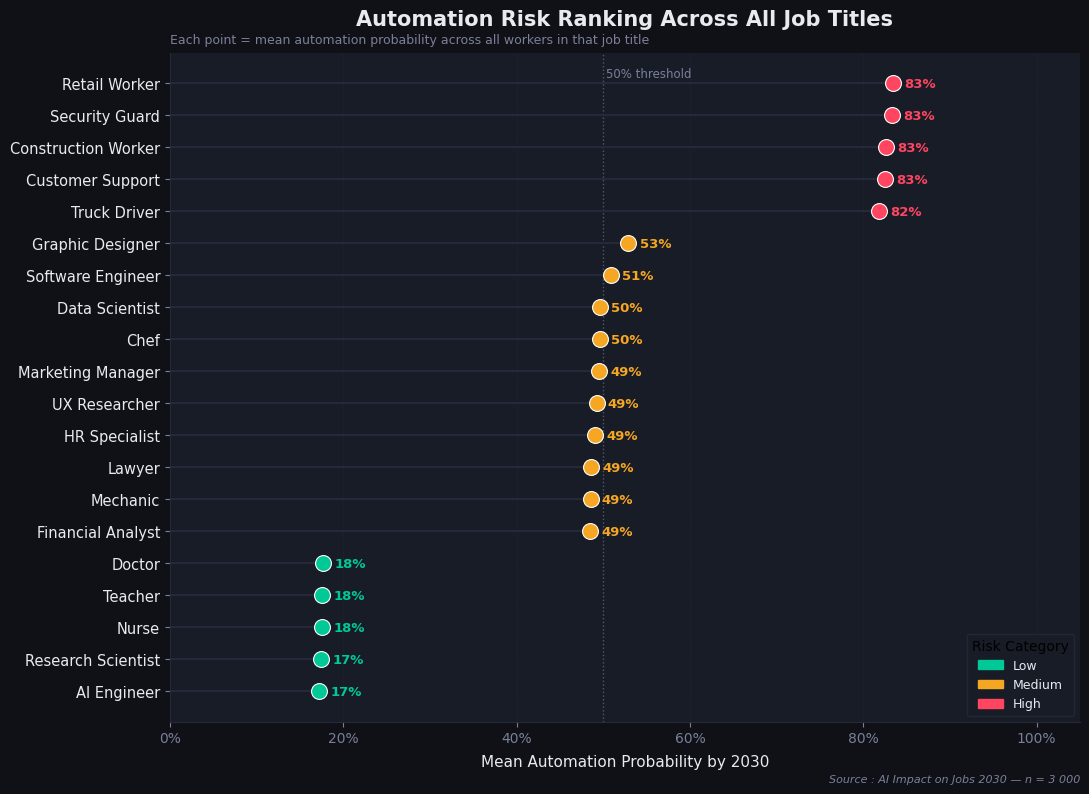

In [7]:
jobs_sorted = jobs.sort_values('automation').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 8))
apply_style(ax, fig)
fig.subplots_adjust(left=0.24, right=0.92, top=0.87, bottom=0.10)

y = np.arange(len(jobs_sorted))
for i, row in jobs_sorted.iterrows():
    col = RISK_COL[row['risk']]
    ax.hlines(i, 0, row['automation'], color=GRID_COL, linewidth=1.5, zorder=2)
    ax.scatter(row['automation'], i, color=col, s=130, zorder=4,
               edgecolors='white', linewidths=0.8)
    ax.text(row['automation'] + 0.013, i, f"{row['automation']:.0%}",
            va='center', fontsize=9.5, color=col, fontweight='bold')

ax.axvline(0.5, color=TEXT_DIM, linewidth=1.0, linestyle=':', alpha=0.6, zorder=1)
ax.text(0.503, len(jobs_sorted) - 0.8, '50% threshold', fontsize=8.5, color=TEXT_DIM)

ax.set_yticks(y)
ax.set_yticklabels(jobs_sorted['Job_Title'], fontsize=10.5, color=TEXT)
ax.set_xlabel('Mean Automation Probability by 2030', fontsize=11, labelpad=6)
ax.set_title('Automation Risk Ranking Across All Job Titles',
             fontsize=15, fontweight='bold', color=TEXT, pad=20)
add_subtitle(ax, 'Each point = mean automation probability across all workers in that job title')
ax.xaxis.set_major_formatter(pct)
ax.set_xlim(0, 1.05)
ax.grid(axis='y', alpha=0.15, color=GRID_COL)
ax.grid(axis='x', alpha=0.5,  color=GRID_COL)

legend_patches = [mpatches.Patch(color=c, label=r) for r, c in RISK_COL.items()]
ax.legend(handles=legend_patches, title='Risk Category', loc='lower right', fontsize=9,
          facecolor=BG2, edgecolor=GRID_COL, labelcolor=TEXT)
add_source(ax)
plt.tight_layout()
plt.show()

**Analyse** : On observe trois clusters bien distincts — les 5 métiers Low Risk (~17%), les 10 métiers Medium (~49–53%) et les 5 métiers High Risk (~82–83%). Le seuil des 50% est une frontière naturelle.

---
## 📊 Graphique 3 — KDE Ridgeline : Distribution de la probabilité d'automatisation par catégorie

**Question** : comment se distribuent les probabilités au sein de chaque catégorie de risque ?

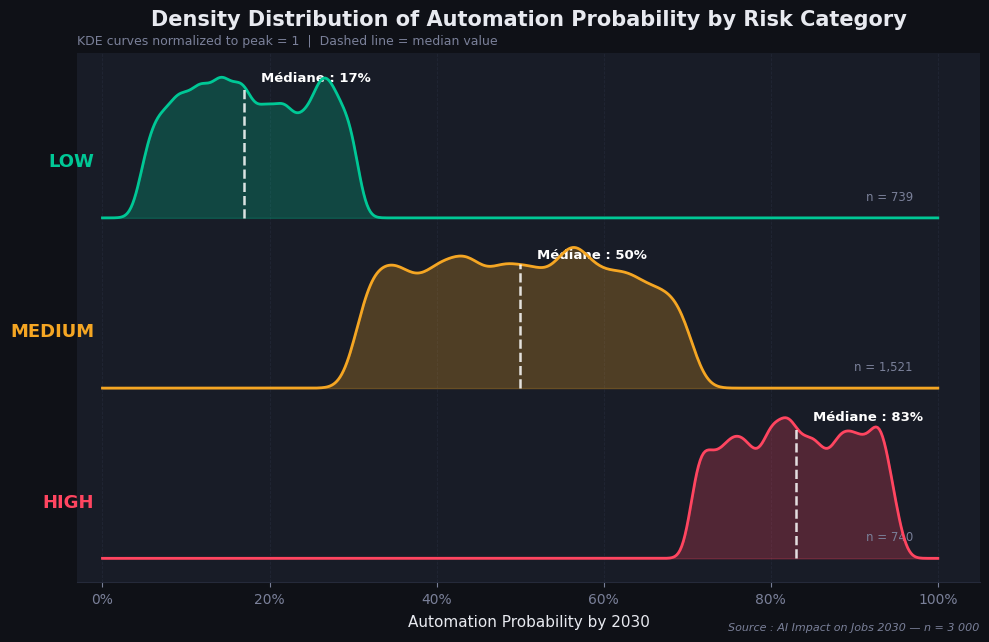

In [8]:
fig, ax = plt.subplots(figsize=(10, 6.5))
apply_style(ax, fig)
fig.subplots_adjust(left=0.05, right=0.93, top=0.87, bottom=0.11)

risk_order = ['High', 'Medium', 'Low']
offsets    = {'High': 0, 'Medium': 1.15, 'Low': 2.30}
x_range    = np.linspace(0, 1, 500)

for risk in risk_order:
    subset   = df[df['Risk_Category'] == risk]['Automation_Probability_2030']
    kde      = gaussian_kde(subset, bw_method=0.14)
    y_kde    = kde(x_range)
    y_norm   = y_kde / y_kde.max()
    off      = offsets[risk]
    col      = RISK_COL[risk]

    ax.fill_between(x_range, off, off + y_norm * 0.95, color=col, alpha=0.25, zorder=3)
    ax.plot(x_range, off + y_norm * 0.95, color=col, linewidth=2.0, zorder=4)

    # Ligne médiane
    med   = subset.median()
    med_y = kde(np.array([med]))[0] / y_kde.max() * 0.95
    ax.vlines(med, off, off + med_y, color='white', linewidth=1.8,
              linestyle='--', zorder=5, alpha=0.85)
    ax.text(med + 0.02, off + med_y + 0.04, f'Médiane : {med:.0%}',
            fontsize=9.5, color='white', fontweight='bold')

    ax.text(-0.01, off + 0.38, risk.upper(), fontsize=13, color=col,
            fontweight='bold', ha='right', va='center')
    ax.text(0.97, off + 0.12, f'n = {len(subset):,}',
            fontsize=8.5, color=TEXT_DIM, ha='right',
            transform=ax.transData)

ax.set_xlabel('Automation Probability by 2030', fontsize=11, labelpad=6)
ax.set_title('Density Distribution of Automation Probability by Risk Category',
             fontsize=15, fontweight='bold', color=TEXT, pad=20)
add_subtitle(ax, 'KDE curves normalized to peak = 1  |  Dashed line = median value')
ax.xaxis.set_major_formatter(pct)
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.set_xlim(-0.03, 1.05)
add_source(ax)
plt.tight_layout()
plt.show()

**Analyse** : Les trois distributions sont très peu superposées — les catégories de risque ont été attribuées de façon cohérente. La catégorie Medium est la plus large (n=1521) et couvre une plage [30%–65%].

---
## 📊 Graphique 4 — Stacked Bar 100% : Répartition du risque par niveau d'éducation

**Question** : un niveau d'éducation plus élevé protège-t-il contre l'automatisation ?

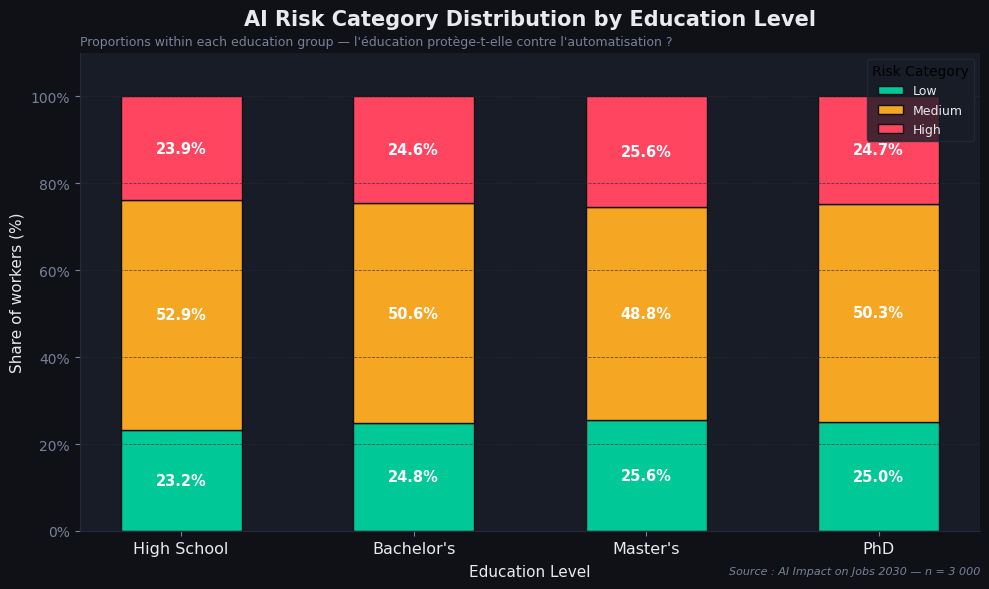

In [9]:
cross = pd.crosstab(df['Education_Level'], df['Risk_Category'], normalize='index') * 100
cross = cross.loc[EDU_ORDER, ['Low', 'Medium', 'High']]

fig, ax = plt.subplots(figsize=(10, 6))
apply_style(ax, fig)
fig.subplots_adjust(left=0.13, right=0.93, top=0.87, bottom=0.12)

x       = np.arange(len(EDU_ORDER))
width   = 0.52
bottoms = np.zeros(len(EDU_ORDER))

for risk in ['Low', 'Medium', 'High']:
    vals = cross[risk].values
    ax.bar(x, vals, bottom=bottoms, width=width,
           color=RISK_COL[risk], label=risk, edgecolor=BG, linewidth=1.0)
    for xi, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 4.5:
            ax.text(xi, b + v / 2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=10.5, color='white', fontweight='bold')
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(EDU_ORDER, fontsize=11.5, color=TEXT)
ax.set_xlabel('Education Level', fontsize=11, labelpad=6)
ax.set_ylabel('Share of workers (%)', fontsize=11)
ax.set_title('AI Risk Category Distribution by Education Level',
             fontsize=15, fontweight='bold', color=TEXT, pad=20)
add_subtitle(ax, 'Proportions within each education group — l\'éducation protège-t-elle contre l\'automatisation ?')
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend(title='Risk Category', loc='upper right', fontsize=9,
          facecolor=BG2, edgecolor=GRID_COL, labelcolor=TEXT)
ax.grid(axis='x', alpha=0)
add_source(ax)
plt.tight_layout()
plt.show()

**Analyse** : Résultat surprenant — la distribution des catégories de risque est quasi-identique quel que soit le niveau d'éducation (~24% High, ~25% Low, ~50% Medium). **L'éducation ne protège pas** de l'automatisation dans ce dataset.

---
## 📊 Graphique 5 — Heatmap : Probabilité d'automatisation par Métier × Éducation

**Question** : pour un même métier, le niveau d'éducation change-t-il le risque d'automatisation ?

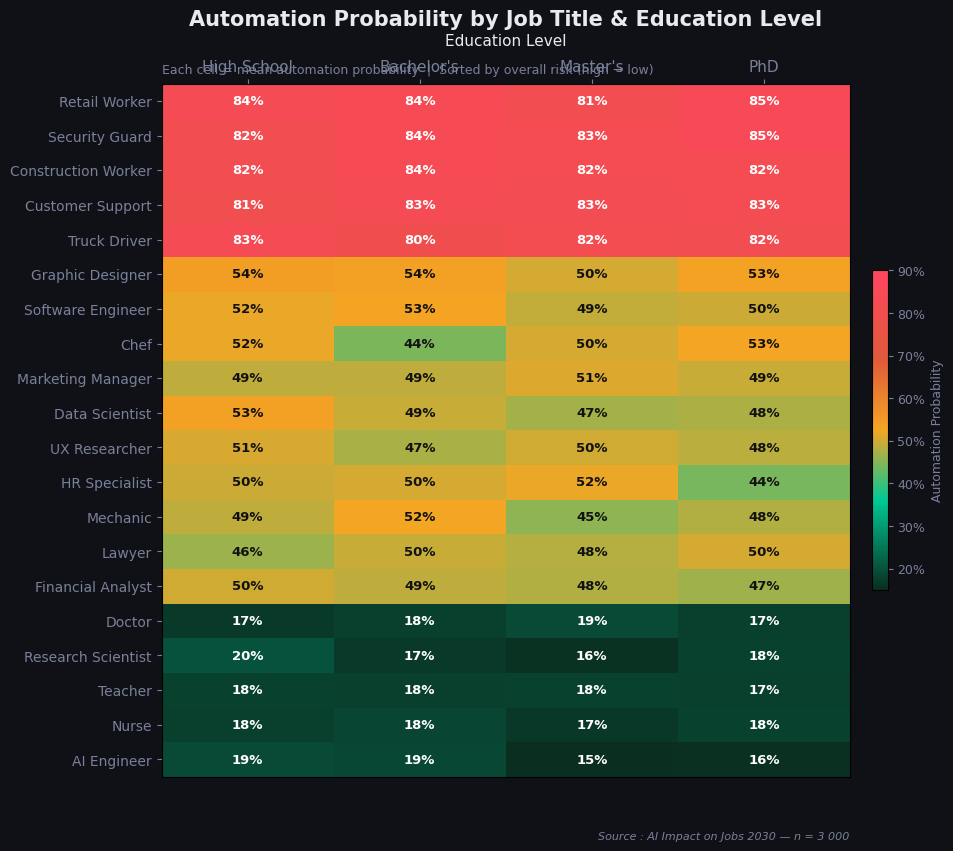

In [10]:
heat = df.groupby(['Job_Title', 'Education_Level'])['Automation_Probability_2030'] \
         .mean().unstack()[EDU_ORDER]
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]

cmap = LinearSegmentedColormap.from_list('risk',
    [(0,'#0a2e20'), (0.28,LOW_C), (0.5,MED_C), (0.72,'#e05a3a'), (1.0,HIGH_C)], N=256)

fig, ax = plt.subplots(figsize=(11, 9))
fig.set_facecolor(BG)
ax.set_facecolor(BG2)
fig.subplots_adjust(left=0.22, right=0.88, top=0.86, bottom=0.09)

im = ax.imshow(heat.values, aspect='auto', cmap=cmap, vmin=0.15, vmax=0.90)

ax.set_xticks(range(len(EDU_ORDER)))
ax.set_xticklabels(EDU_ORDER, fontsize=11, color=TEXT)
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index, fontsize=10, color=TEXT)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xlabel('Education Level', fontsize=11, labelpad=10, color=TEXT)
ax.set_title('Automation Probability by Job Title & Education Level',
             fontsize=15, fontweight='bold', color=TEXT, pad=42)
add_subtitle(ax, 'Each cell = mean automation probability  |  Sorted by overall risk (high → low)')

# Annotations des cellules
for i in range(len(heat)):
    for j in range(len(EDU_ORDER)):
        val = heat.values[i, j]
        tc  = 'white' if val > 0.58 or val < 0.28 else '#111'
        ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                fontsize=9.5, color=tc, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.022, pad=0.03)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
cbar.ax.tick_params(colors=TEXT_DIM, labelsize=9)
cbar.set_label('Automation Probability', color=TEXT_DIM, fontsize=9)

ax.grid(False)
ax.tick_params(colors=TEXT_DIM)
add_source(ax)
plt.show()

**Analyse** : Pour chaque métier, la probabilité d'automatisation varie très peu selon le niveau d'éducation. Un Truck Driver reste à ~82% quel que soit son diplôme. Le métier est le déterminant principal du risque, pas le niveau d'éducation.

---
## 📊 Graphique 6 — Diverging Bar : Écart de salaire par rapport à la moyenne du marché

**Question** : quels métiers payent au-dessus ou en-dessous du salaire moyen, et quel est leur niveau de risque IA ?

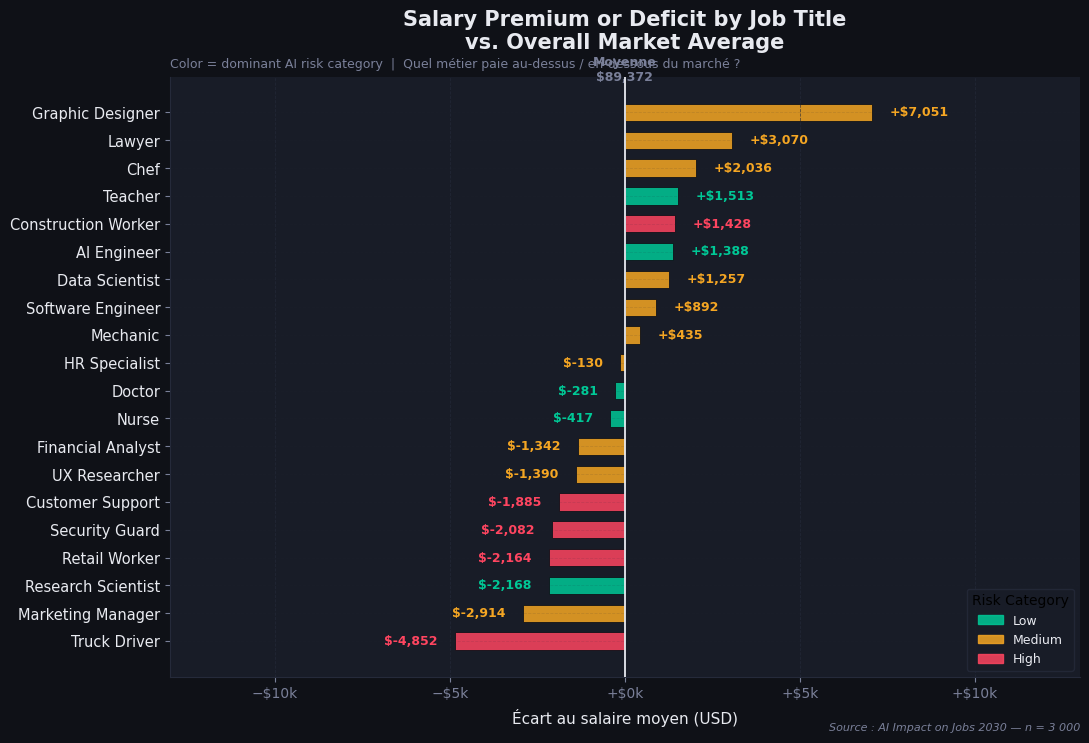

In [11]:
grand_mean = df['Average_Salary'].mean()
job_sal = df.groupby('Job_Title').agg(
    salary = ('Average_Salary', 'mean'),
    risk   = ('Risk_Category', lambda x: x.value_counts().idxmax())
).reset_index()
job_sal['delta'] = job_sal['salary'] - grand_mean
job_sal = job_sal.sort_values('delta').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7.5))
apply_style(ax, fig)
fig.subplots_adjust(left=0.22, right=0.93, top=0.87, bottom=0.12)

y = np.arange(len(job_sal))
for i, row in job_sal.iterrows():
    col = RISK_COL[row['risk']]
    ax.barh(i, row['delta'], color=col, alpha=0.85,
            edgecolor=BG, linewidth=0.7, height=0.62)
    sign = '+' if row['delta'] >= 0 else ''
    xpos = row['delta'] + (500 if row['delta'] >= 0 else -500)
    ha   = 'left' if row['delta'] >= 0 else 'right'
    ax.text(xpos, i, f"{sign}${row['delta']:,.0f}", va='center',
            fontsize=9, color=col, fontweight='bold', ha=ha)

ax.axvline(0, color=TEXT, linewidth=1.3, zorder=5)
ax.text(0, len(job_sal) + 0.15, f'Moyenne\n${grand_mean:,.0f}',
        ha='center', fontsize=9, color=TEXT_DIM, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(job_sal['Job_Title'], fontsize=10.5, color=TEXT)
ax.set_xlabel('Écart au salaire moyen (USD)', fontsize=11, labelpad=6)
ax.set_title('Salary Premium or Deficit by Job Title\nvs. Overall Market Average',
             fontsize=15, fontweight='bold', color=TEXT, pad=20)
add_subtitle(ax, 'Color = dominant AI risk category  |  Quel métier paie au-dessus / en-dessous du marché ?')
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, _: f'+${x/1000:.0f}k' if x >= 0 else f'−${abs(x)/1000:.0f}k'))
ax.set_xlim(-13000, 13000)
ax.grid(axis='y', alpha=0.12, color=GRID_COL)

legend_patches = [mpatches.Patch(color=c, label=r, alpha=0.85) for r, c in RISK_COL.items()]
ax.legend(handles=legend_patches, title='Risk Category', loc='lower right', fontsize=9,
          facecolor=BG2, edgecolor=GRID_COL, labelcolor=TEXT)
add_source(ax)
plt.tight_layout()
plt.show()

**Analyse** : Les écarts de salaire sont modestes (±10k) et ne corrèlent pas clairement avec le risque IA. Le Graphic Designer (Medium) et le Lawyer (Medium) sont les mieux payés ; le Truck Driver (High) est en-dessous de la moyenne malgré un risque élevé.

---
## Conclusion

| Insight | Résultat |
|---|---|
| Le salaire protège-t-il ? | ❌ Non — pas de corrélation salaire/risque |
| L'éducation protège-t-elle ? | ❌ Non — distribution quasi-identique par niveau |
| Qui est le plus à risque ? | Retail Worker, Truck Driver, Security Guard (~83%) |
| Qui est le moins à risque ? | AI Engineer, Research Scientist, Nurse (~17%) |
| Variable la plus discriminante | Le **métier** lui-même, pas le profil individuel |